# **1. SVM Classification**

## **1-1. Load Dataset**

In [ ]:
# Load dataset
from sklearn.datasets import load_breast_cancer

cancer = load_breast_cancer() # 이진분류를 위한1 데이터셋을 새로 로드

print(cancer.keys())
data = cancer["data"]     # 실제 데이터 (모델 인풋, X)
target = cancer["target"] # 예측 값 (실제 아웃풋, Y)
feature_name = cancer["feature_names"]

## **1-2. Data Analysis**

In [ ]:
!pip3 install seaborn

In [ ]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
print(feature_name) # 어떤 피쳐가 있는지 확인하기

In [ ]:
# X data
feature_use = ['mean radius', 'mean texture', 'mean perimeter', 'mean area']
data_for_analysis = data[:, :4]       # 일부 데이터만을 활용하여 데이터 분석
df = pd.DataFrame(data_for_analysis)  # 데이터 프레임 형태로 변환
df.columns = feature_use

# Y data
df["target"] = target

In [ ]:
count_label = np.bincount(df.target)
label_name = ["Malignant", "Benign"] # 악성, 양성
plt.bar(label_name, count_label, color=["blue", "purple"])
plt.title("The number of the each label")

* reference: https://seaborn.pydata.org/generated/seaborn.pairplot.html

In [ ]:
sns.pairplot(df,hue="target", vars=feature_use)

* reference: https://seaborn.pydata.org/generated/seaborn.heatmap.html

In [ ]:
sns.heatmap(df.corr(), annot=True)
plt.title("The relationship between each features")

## **1-3. Model Training**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data, target, test_size=0.33, random_state=1213) # 데이터 분할

In [ ]:
from sklearn.svm import SVC # Support Vector Classifier
from sklearn.metrics import classification_report

* AUROC curve reference: https://angeloyeo.github.io/2020/08/05/ROC.html

In [ ]:
clf = SVC(probability=True) # 분류기 정의, probability 변수는 이후에 AUROC 커브를 그리기 위함.
clf.fit(X_train, y_train) # 분류기 훈련
y_pred = clf.predict(X_test) # 예측값 추론
print(classification_report(y_test, y_pred)) # 결과 리포트

### **Testing Different Parameter of SVC**

In [ ]:
clf2 = SVC(kernel="linear", probability=True) # 분류기 정의
clf2.fit(X_train, y_train) # 분류기 훈련
y_pred = clf2.predict(X_test) # 예측값 추론
print(classification_report(y_test, y_pred)) # 결과 리포트

### **5-Fold Cross Validation**
* 실제로 kernel 변경이 정확도 향상에 도움이 있었는지 5폴드 교차검증을 통해 증명

In [ ]:
from sklearn.model_selection import cross_val_score

scores1 = cross_val_score(clf, data, target, cv=5)
scores2 = cross_val_score(clf2, data, target, cv=5)

print(f"일반 SVC모델 5폴드 정확도 평균: {np.mean(scores1):.2f}")
print(f"Linear커널 SVC모델 5폴드 정확도 평균: {np.mean(scores2):.2f}")

# **2. Analysis**
* kernel에 따라 성능이 달라지는 것을 확인해볼 수 있음
* 데이터의 형태에 따라서 여러 파라미터를 변경해주어야 한다.
* 유방암 데이터의 경우, 선형적으로 데이터를 분할하면 데이터의 분포를 잘 나눌 수 있기 때문에, 분할 방법을 의미하는 파라미터인 kernel을 변경했을 때, 성능이 올라감을 확인할 수 있었다.

### **2-1. Analysis1 - Confusion Matrix**

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

prediction = clf.predict(X_test)

labels = [
    "Malignant",
    "Benign",
]

cm2 = confusion_matrix(y_test, prediction)
sns.heatmap(cm2, annot=True, fmt='d',cmap='Blues')
plt.xlabel('Prediction')
plt.ylabel('True label')
plt.xticks([0.5,1.5], labels)
plt.yticks([0.5,1.5], labels)
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

prediction2 = clf2.predict(X_test)

labels = [
    "Malignant",
    "Benign",
]

cm2 = confusion_matrix(y_test, prediction2)
sns.heatmap(cm2, annot=True, fmt='d',cmap='Blues')
plt.xlabel('Prediction')
plt.ylabel('True label')
plt.xticks([0.5,1.5], labels)
plt.yticks([0.5,1.5], labels)
plt.show()

### **2-2. Analysis2 - AUROC Curve**
* 1번 모델과 2번 모델 AUROC 커브 비교를 통해 성능을 검증한다.

In [ ]:
y_score1 = clf.predict_proba(X_test)[:, 1]
y_score2 = clf2.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import roc_curve

fpr_model1, tpr_model1, _ = roc_curve(y_test, y_score1) # 모델1에 대한 roc_curve 계산
fpr_model2, tpr_model2, _ = roc_curve(y_test, y_score2) # 모델2에 대한 roc_curve 계산

ns_probs = [0 for _ in range(len(y_test))] # 기준선을 그리기 위해 모든 확률이 0인 데이터를 생성
fpr_none, tpr_none, _  = roc_curve(y_test, ns_probs) # 기준선에 대한 roc_curve 계산

In [ ]:
plt.plot(fpr_none, tpr_none, linestyle='--', label='No Skill')
plt.plot(fpr_model1, tpr_model1, marker='.', label='SVC-No Parameter')
plt.plot(fpr_model2, tpr_model2, marker='.', label='Model-Kernel: Linear')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

## **2-3. GridSearchCV**
* 하이퍼 파라미터 튜닝을 위한 grid serach 수행
* 가능한 모든 하이퍼 파라미터의 조합을 시도하여 최적의 조합을 찾아내는 방법

In [ ]:
from sklearn.model_selection import GridSearchCV
import timeit

In [ ]:
clf = SVC(probability=True)

# Grid Search를 위한 파라미터 조합 정의
parameter = {
    'kernel' : ['linear', 'rbf', 'poly'],     # 커널 종류. 선형 커널, RBF 커널, 하이퍼볼릭 탄젠트 커널
    'C': [0.1, 1, 10, 50],                    # 오분류 허용 정도
    }

# Grid Search 적용
grid_search = GridSearchCV(clf, parameter, n_jobs=-1, cv=5) # cv = cross validation fold 수

In [ ]:
# start_time 변수에 현재 시간을 저장
start_time = timeit.default_timer()

# Grid Search 를 이용해 학습
grid_search.fit(X_train, y_train)

print("%0.3fs seconds" %(timeit.default_timer() - start_time))

In [ ]:
# 최적 파라미터 및 최적 점수 출력
print("Best parameters found: ", grid_search.best_params_)
print("Best score: ", grid_search.best_score_)

In [ ]:
# 테스트 데이터셋에 대한 최종 성능 평가
svc_svm_best = grid_search.best_estimator_
accuracy = svc_svm_best.score(X_test, y_test)
print('The accuracy on testing set is : %.1f%%' %(accuracy*100))

# **3. 실습과제**

1. iris dataset을 불러오세요.
2. label이 0, 1인 데이터만 추출하세요. (hint: dataframe으로 만든 뒤, target이 0, 1인 row만 추출 / 결과는 아래 그림과 같음)

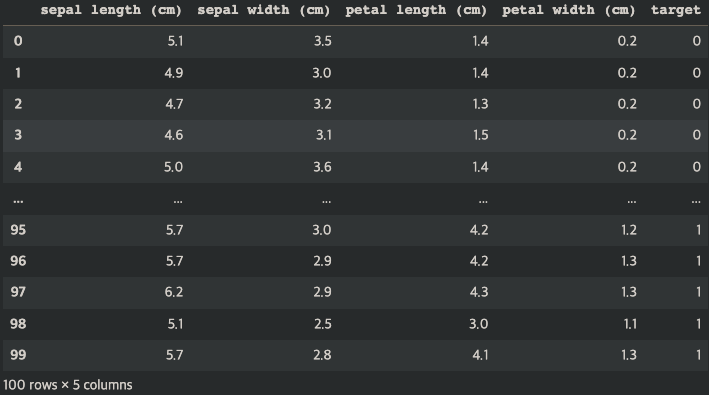

3. Support Vector Classifier를 학습시키고, classification report를 출력하세요.

In [ ]:
# 1. iris dataset을 불러오세요.

# Your code here

In [ ]:
# 2. label이 0, 1인 데이터만 추출하세요. (hint: dataframe으로 만든 뒤, target이 0, 1인 row만 추출 / 결과는 아래 그림과 같음)

# Your code here

In [ ]:
df_processed

In [ ]:
# 3. Support Vector Classifier를 학습시키고, classification report를 출력하세요.

# Your code here